# EDA for the Trainning set

In [1]:
import json
import os
import sys
import argparse
import random
from collections import Counter, defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pycocotools import mask as mask_utils

ROOT_DIR   = Path.cwd().parent
DATA_DIR   = ROOT_DIR / "data" / "nvidia_warehouse_dataset"
JSON_PATH  = DATA_DIR / "train.json"
IMAGE_DIR  = DATA_DIR / "train" / "images"
DEPTH_DIR  = DATA_DIR / "train" / "depths"

## 0. Check number of images and QA pairs

In [ ]:
n_rgb   = len(list(IMAGE_DIR.iterdir()))
n_depth = len(list(DEPTH_DIR.iterdir()))

with open(os.path.join(DATA_DIR, "train.json"), "r") as f:
    data = json.load(f)
n_qa = len(data)

print(f"RGB images:  {n_rgb:,}")
print(f"Depth maps:  {n_depth:,}")
print(f"QA pairs:    {n_qa:,}")
print(f"QA/image:    {n_qa / n_rgb:.1f}")

RGB images:  78,209
Depth maps:  78,209
QA pairs:    499,083
QA/image:    6.4


## 1. Task category distribution

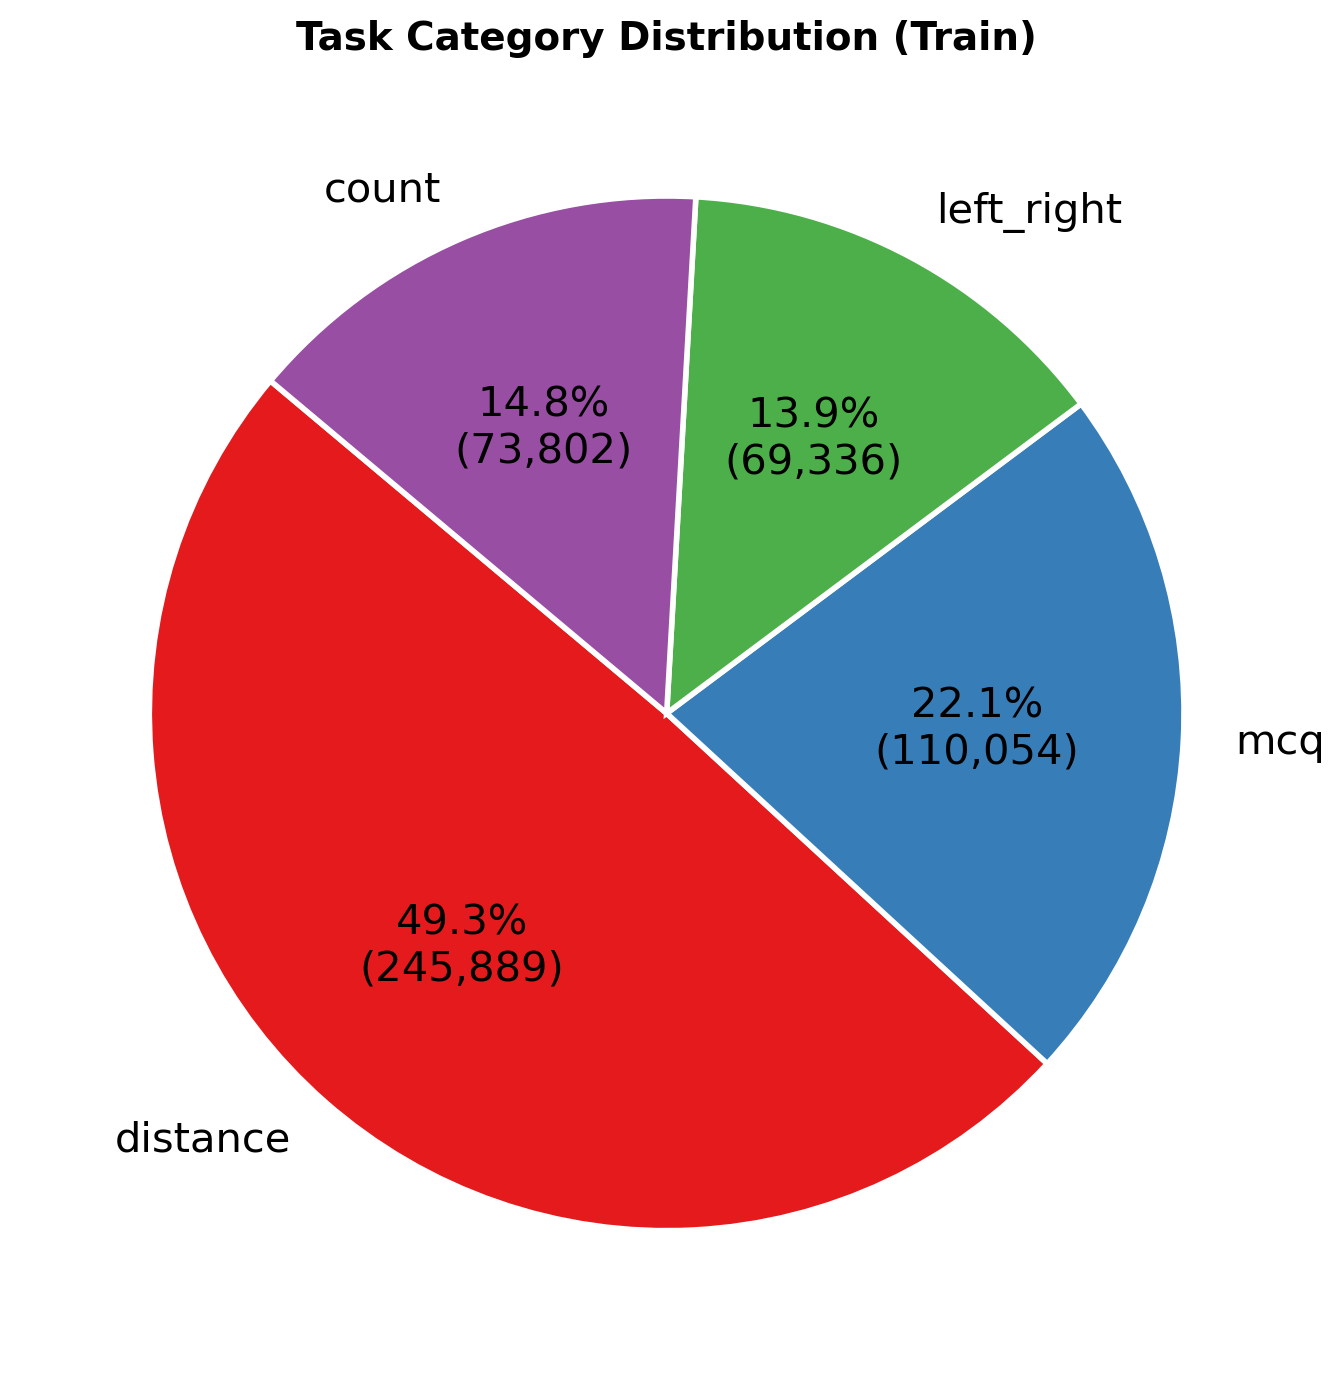

In [3]:
cats = Counter(e["category"] for e in data)

labels = list(cats.keys())
sizes = list(cats.values())

colors = sns.color_palette("Set1", len(labels))
fig, ax = plt.subplots(figsize=(7, 7), dpi=200)
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, autopct=lambda p: f"{p:.1f}%\n({int(p*sum(sizes)/100):,})",
    startangle=140, textprops={"fontsize": 15},
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
for t in autotexts:
    t.set_fontsize(15)
ax.set_title("Task Category Distribution (Train)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Answer Distribution

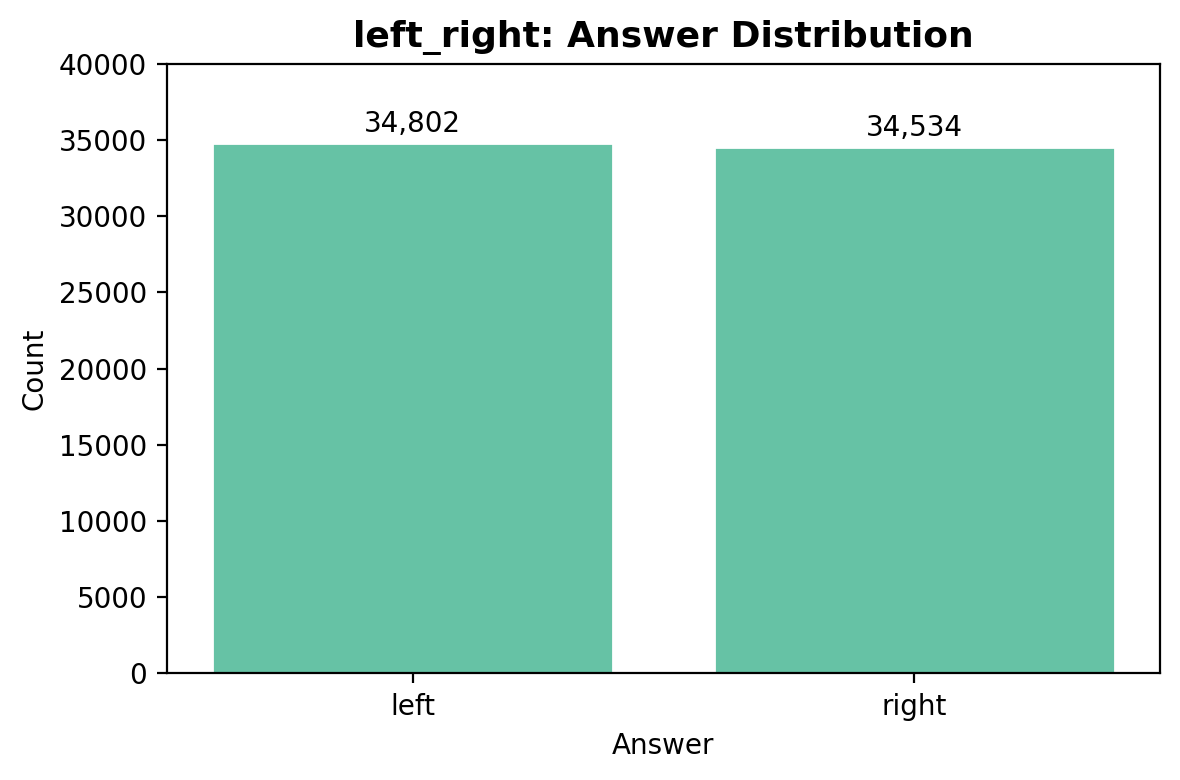

In [12]:
by_cat = defaultdict(list)
for e in data:
    by_cat[e["category"]].append(e["normalized_answer"])
lr_counts = Counter(str(v) for v in by_cat["left_right"])
labels = sorted(lr_counts.keys())
vals = [lr_counts[l] for l in labels]

fig, ax = plt.subplots(figsize=(6, 4), dpi=200)
bars = ax.bar(labels, vals, color=sns.color_palette("Set2")[0], edgecolor="white")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
            f"{v:,}", ha="center", va="bottom", fontsize=10)
ax.set_title("left_right: Answer Distribution", fontsize=13, fontweight="bold")
ax.set_ylim((0,40_000))
ax.set_xlabel("Answer")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

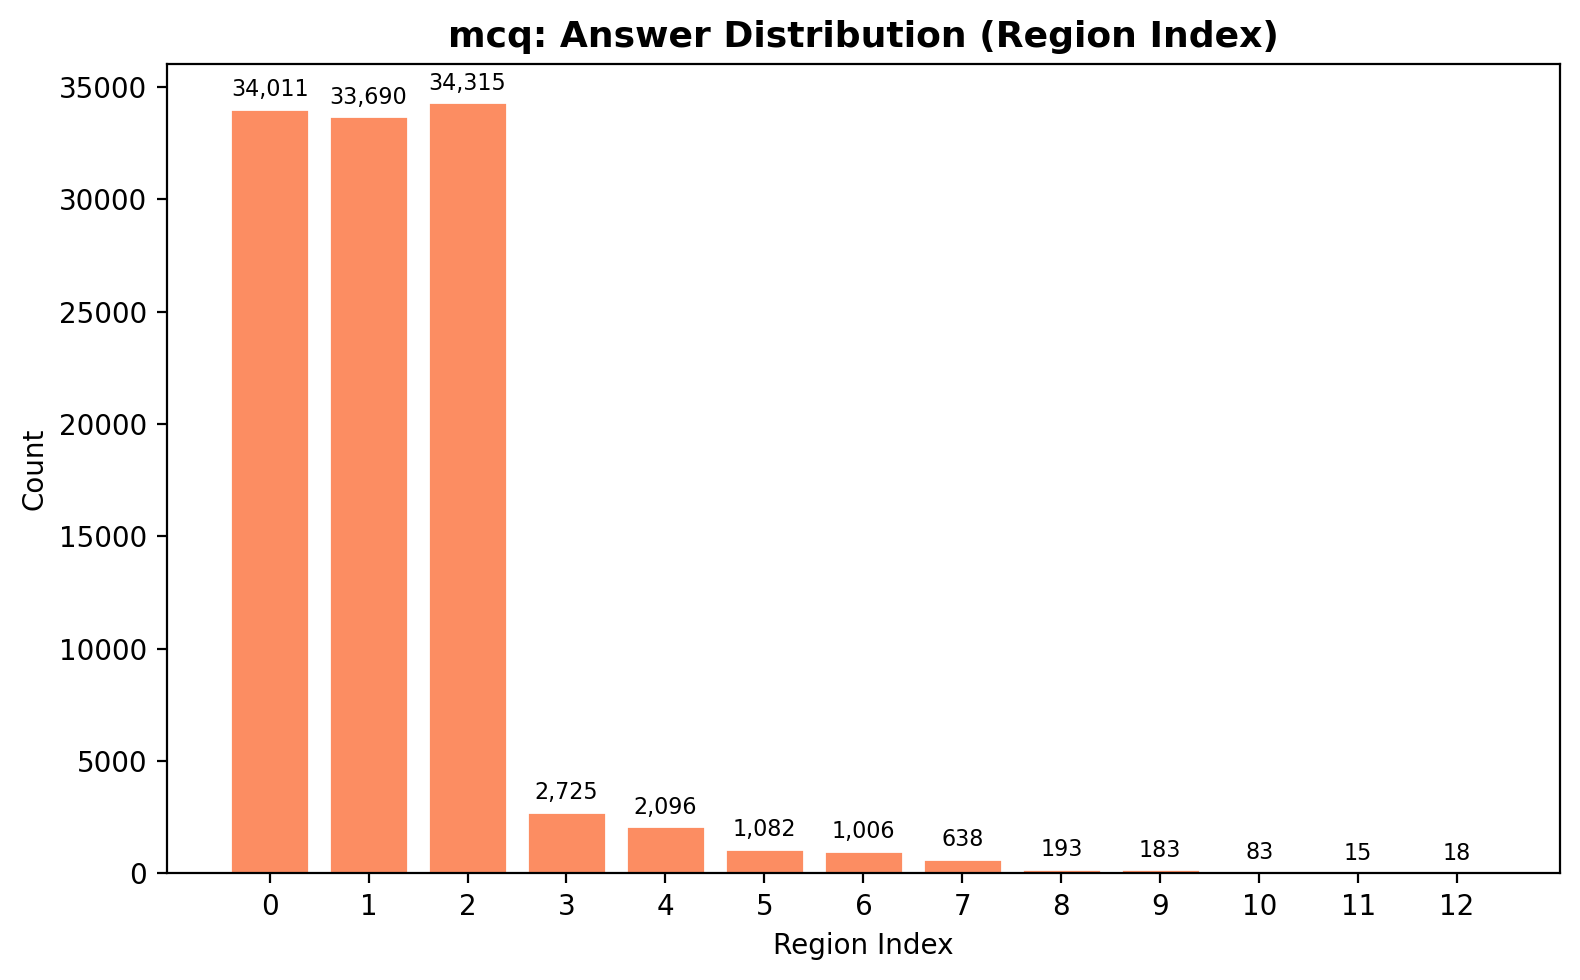

In [18]:
mcq_counts = Counter(str(v) for v in by_cat["mcq"])
labels = sorted(mcq_counts.keys(), key=lambda x: int(x) if x.isdigit() else 999)
vals = [mcq_counts[l] for l in labels]

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
bars = ax.bar(labels, vals, color=sns.color_palette("Set2")[1], edgecolor="white")
for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f"{v:,}", ha="center", va="bottom", fontsize=8)
ax.set_title("mcq: Answer Distribution (Region Index)", fontsize=13, fontweight="bold")
ax.set_xlabel("Region Index")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


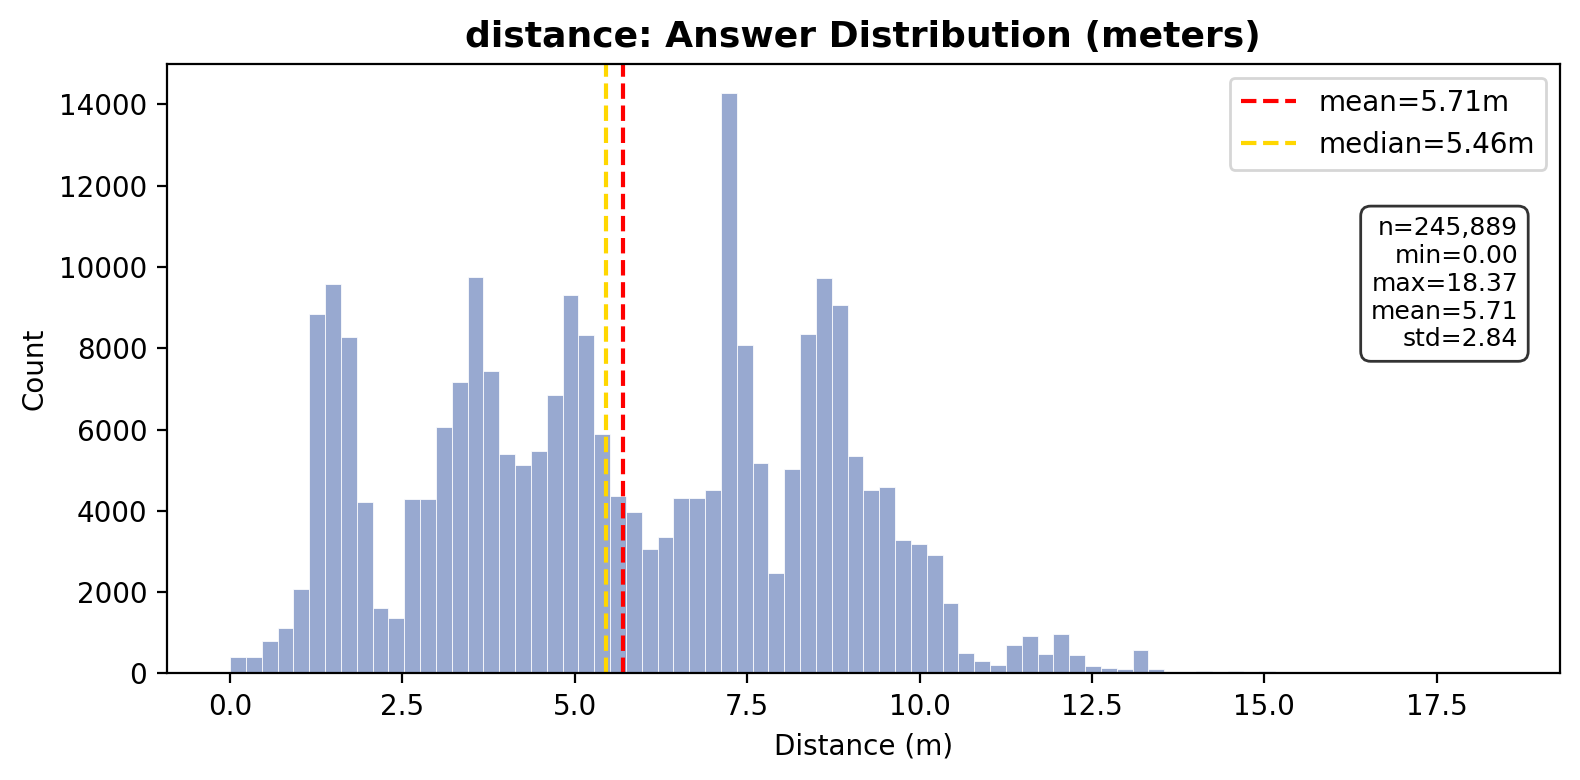

In [ ]:
dist_vals = [float(v) for v in by_cat["distance"]]

fig, ax = plt.subplots(figsize=(8, 4), dpi=200)
ax.hist(dist_vals, bins=80, color=sns.color_palette("Set2")[2], edgecolor="white", linewidth=0.3, alpha=0.9)
ax.axvline(np.mean(dist_vals), color="red", linestyle="--", linewidth=1.5, label=f"mean={np.mean(dist_vals):.2f}m")
ax.axvline(np.median(dist_vals), color="gold", linestyle="--", linewidth=1.5, label=f"median={np.median(dist_vals):.2f}m")
ax.set_title("distance: Answer Distribution (meters)", fontsize=13, fontweight="bold")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Count")
ax.legend()

stats = f"n={len(dist_vals):,}\nmin={min(dist_vals):.2f}\nmax={max(dist_vals):.2f}\nmean={np.mean(dist_vals):.2f}\nstd={np.std(dist_vals):.2f}"
ax.text(0.97, 0.75, stats, transform=ax.transAxes, fontsize=9,
        va="top", ha="right", bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.show()

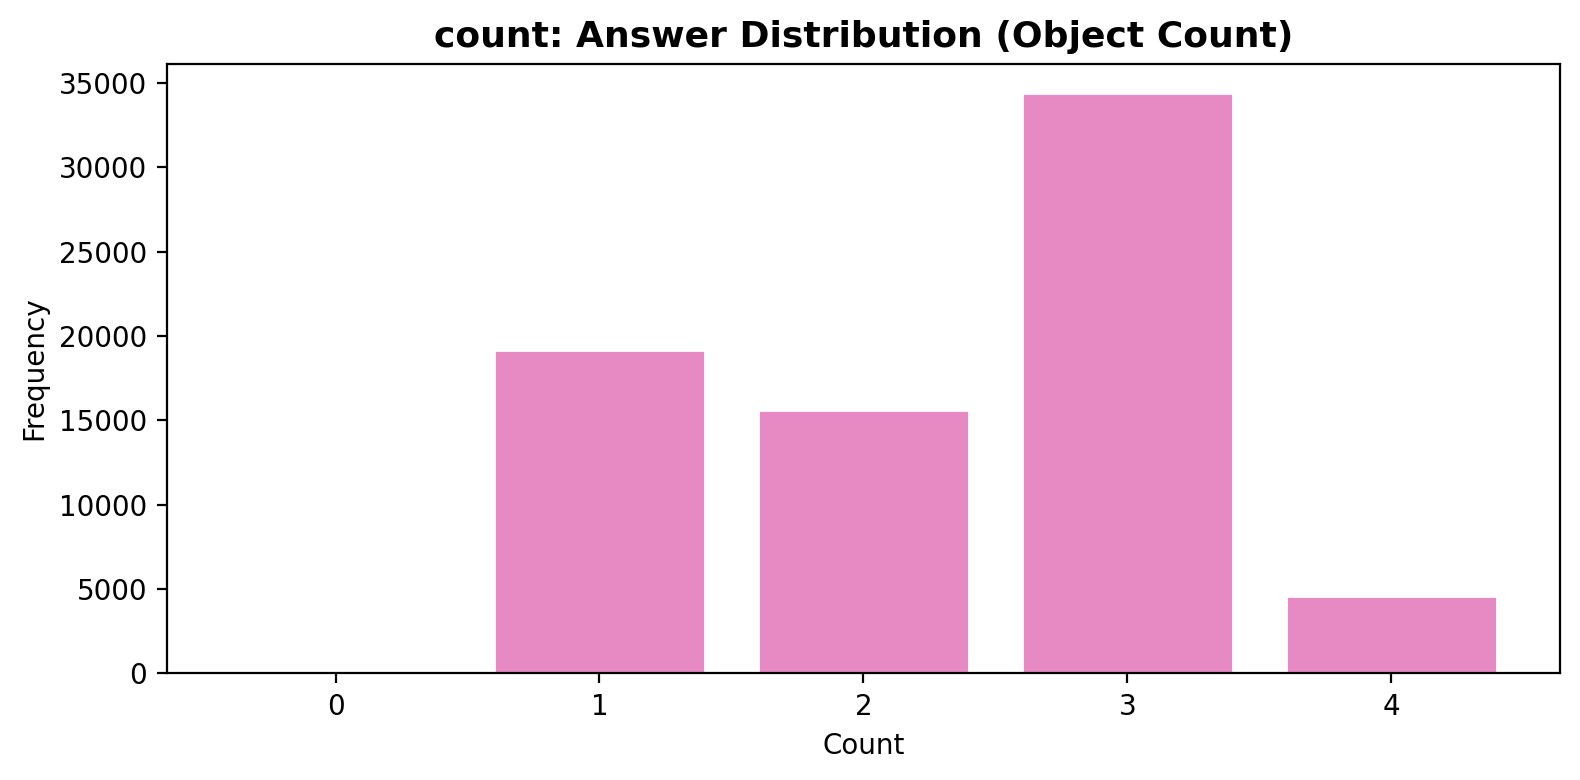

In [ ]:
count_vals = Counter(int(v) for v in by_cat["count"])
labels = sorted(count_vals.keys())
vals = [count_vals[l] for l in labels]

fig, ax = plt.subplots(figsize=(8, 4), dpi=200)
bars = ax.bar([str(l) for l in labels], vals, color=sns.color_palette("Set2")[3], edgecolor="white")
ax.set_title("count: Answer Distribution (Object Count)", fontsize=13, fontweight="bold")
ax.set_xlabel("Count")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## 3. Mask & Question Analysis

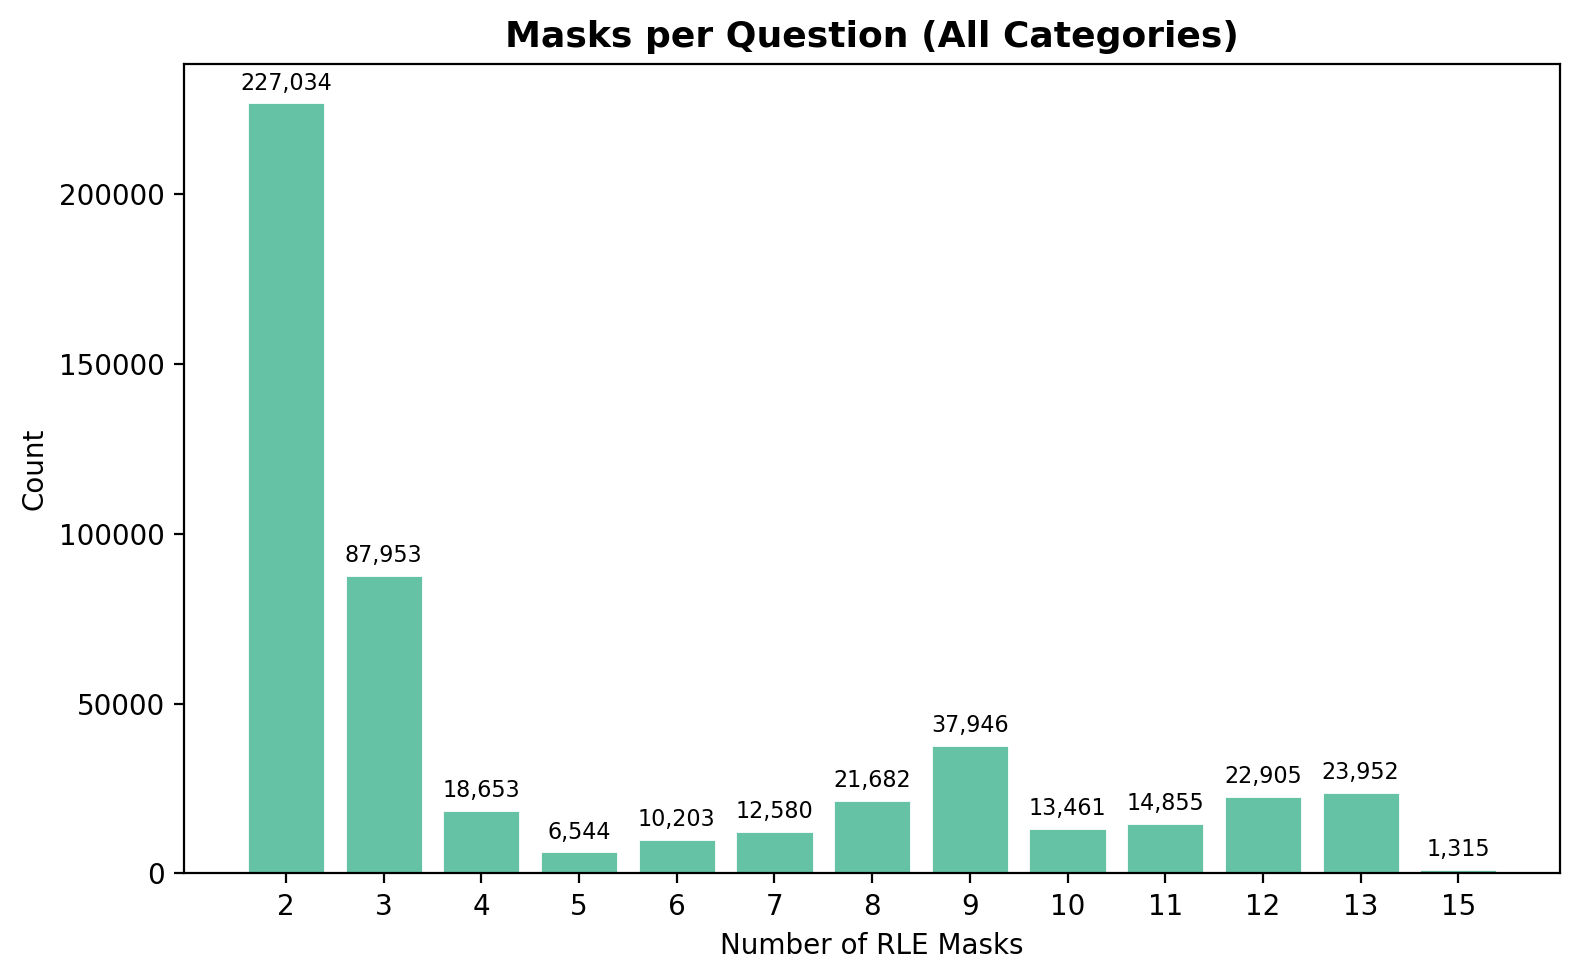

In [4]:
mask_counts = [len(e["rle"]) for e in data]

mc = Counter(mask_counts)
labels = sorted(mc.keys())
vals = [mc[l] for l in labels]

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
bars = ax.bar([str(l) for l in labels], vals, color=sns.color_palette("Set2")[0], edgecolor="white")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
            f"{v:,}", ha="center", va="bottom", fontsize=8)
ax.set_title("Masks per Question (All Categories)", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of RLE Masks")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

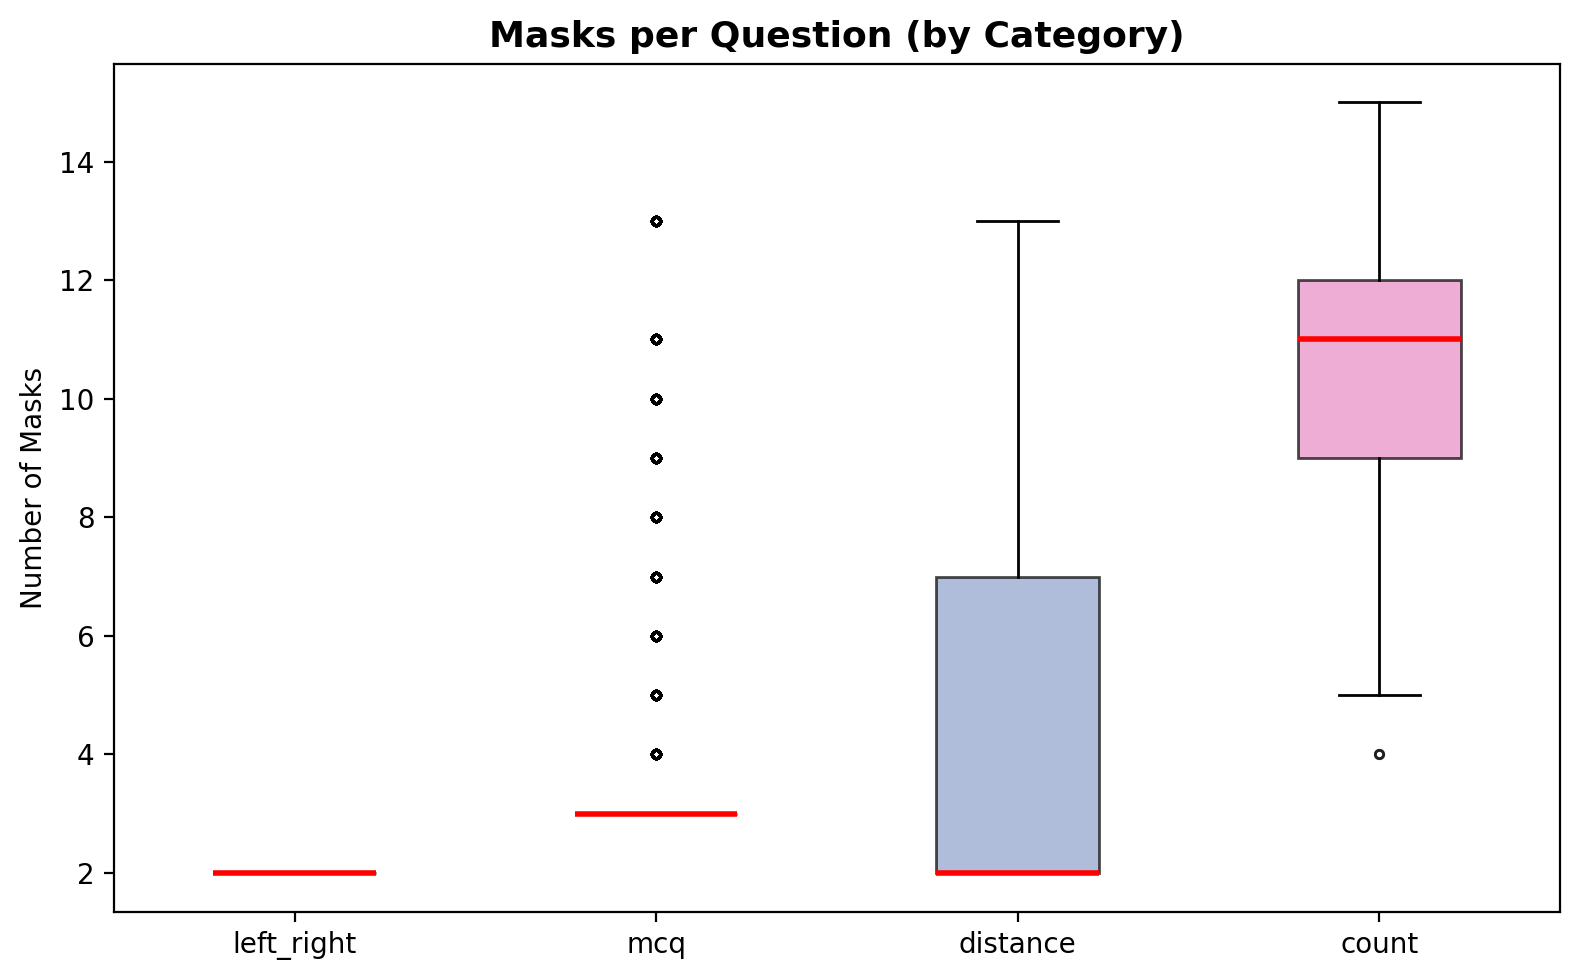

In [5]:
masks_by_cat = defaultdict(list)
for e in data:
    masks_by_cat[e["category"]].append(len(e["rle"]))

cat_order = ["left_right", "mcq", "distance", "count"]
cat_data = [masks_by_cat[c] for c in cat_order]
colors = sns.color_palette("Set2", len(cat_order))

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
bp = ax.boxplot(cat_data, tick_labels=cat_order, patch_artist=True, showfliers=True,
                flierprops=dict(marker="o", markersize=3, alpha=0.5))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp["medians"]:
    median.set_color("red")
    median.set_linewidth(2)
ax.set_title("Masks per Question (by Category)", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Masks")
plt.tight_layout()
plt.show()

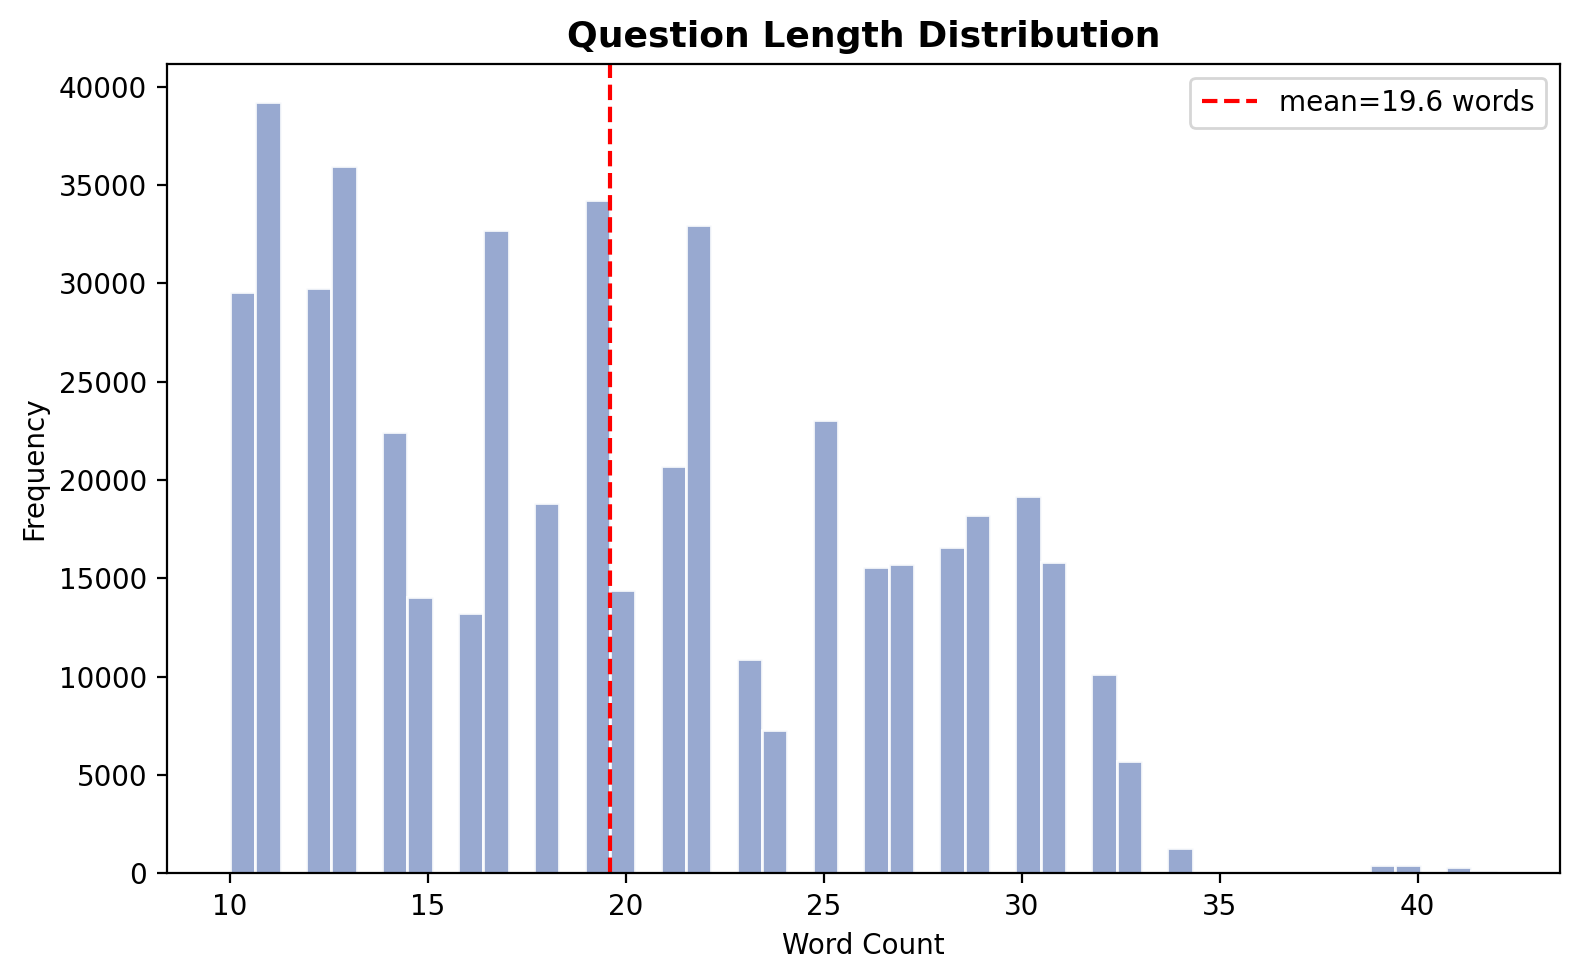

In [6]:
question_lens = []
for e in data:
    q = e["conversations"][0]["value"].replace("<image>\n", "").replace("<image>", "")
    question_lens.append(len(q.split()))

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
ax.hist(question_lens, bins=50, color=sns.color_palette("Set2")[2], edgecolor="white", alpha=0.9)
ax.axvline(np.mean(question_lens), color="red", linestyle="--", linewidth=1.5,
           label=f"mean={np.mean(question_lens):.1f} words")
ax.set_title("Question Length Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

## 4.